In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('/content/abalone.csv')

In [3]:
df.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [4]:
# Ask Six Questions Before moving forward
df.shape

(4177, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


In [6]:
df.isnull().sum()

,0
Sex,0
Length,0
Diameter,0
Height,0
Whole weight,0
Shucked weight,0
Viscera weight,0
Shell weight,0
Rings,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [10]:
#  Encoding

df['Sex'].value_counts()

,count
Sex,
M,1528
I,1342
F,1307


In [11]:
df['Sex'] = df['Sex'].map({'M':0,'F':1,'I':2})

In [12]:
df['Sex'].value_counts()

,count
Sex,
0,1528
2,1342
1,1307


In [14]:
corr = df.corr()

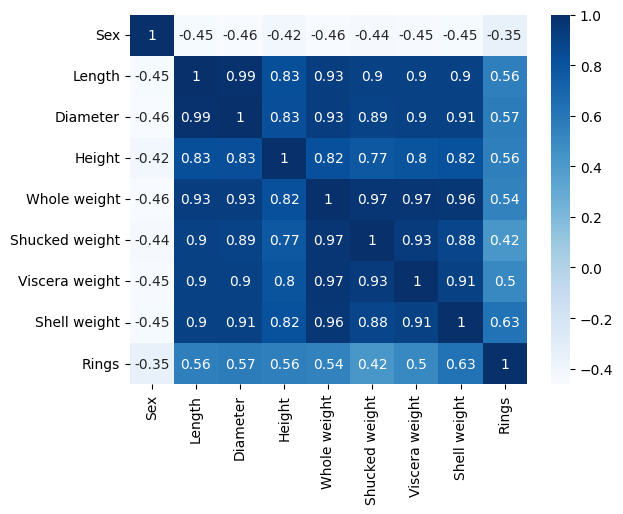

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr, annot=True, cbar=True, cmap='Blues');

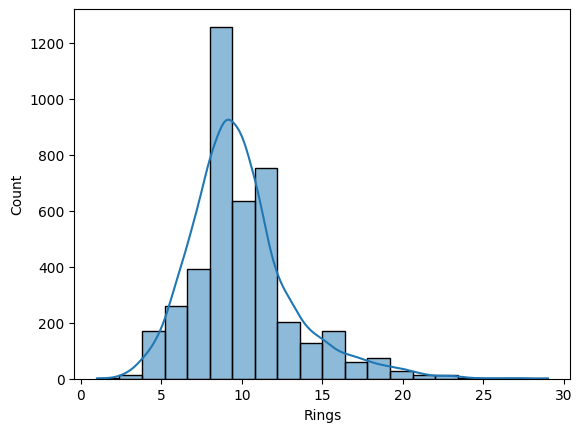

In [18]:
sns.histplot(df['Rings'], kde=True, bins=20);

In [20]:
df['Rings'].value_counts()

,count
Rings,
9,689
10,634
8,568
11,487
7,391
12,267
6,259
13,203
14,126


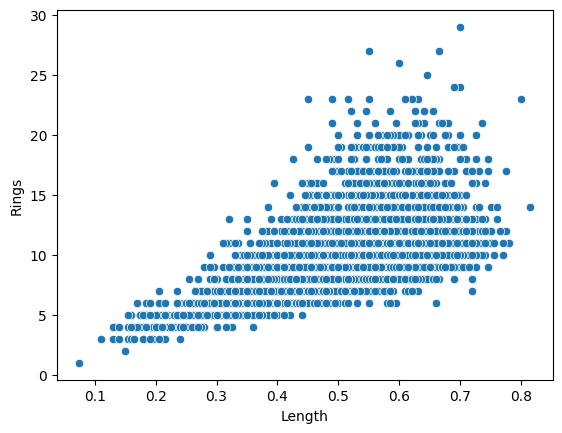

In [21]:
# Scatter plot of length vs age
sns.scatterplot(x='Length', y='Rings', data=df);

In [22]:
X = df.drop('Rings', axis=1)
y = df['Rings']

In [23]:
from sklearn.model_selection import train_test_split
#----------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=44, shuffle =True)

#Splitted Data
print('X_train shape is ' , X_train.shape)
print('X_test shape is ' , X_test.shape)
print('y_train shape is ' , y_train.shape)
print('y_test shape is ' , y_test.shape)

X_train shape is  (2798, 8)
X_test shape is  (1379, 8)
y_train shape is  (2798,)
y_test shape is  (1379,)


In [24]:
# Standarization the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
X_test_scaled

array([[ 1.26685129, -0.84348408, -0.85559017, ..., -1.02431456,
        -1.2200128 , -1.07165893],
       [ 1.26685129, -0.29565996, -0.3469336 , ..., -0.71130713,
        -0.79435801, -0.69365458],
       [-1.15270496,  0.37858511,  0.51778258, ...,  0.81970749,
         0.20341344,  0.06948628],
       ...,
       [-1.15270496,  1.0949705 ,  0.82297652, ...,  1.26426877,
         1.03183835,  0.8896844 ],
       [ 0.05707316,  1.72707526,  1.48423007, ...,  1.3368502 ,
         0.13933637,  1.80616664],
       [ 0.05707316,  0.21002385,  0.21258863, ...,  0.15513374,
         0.12560557, -0.12308197]])

In [29]:
# Training Models

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error

# Instantiate the models directly in the list
Models = [
    XGBRegressor(),
    CatBoostRegressor(verbose=0),
    LGBMRegressor(verbose=-1),
    GradientBoostingRegressor(),
    RandomForestRegressor(),
    DecisionTreeRegressor()
]

for Model in Models:
    print(f'for Model {str(Model).split("(")[0]}')
    Model.fit(X_train, y_train)
    print(f'Train Score is : {Model.score(X_train, y_train)}')
    print(f'Test Score is : {Model.score(X_test, y_test)}')
    y_pred = Model.predict(X_test)
    print(f'MAE value is  : {mean_absolute_error(y_test, y_pred)}')
    print(f'MSE value is  : {mean_squared_error(y_test, y_pred)}')
    print(f'MdSE value is  : {median_absolute_error(y_test, y_pred)}')
    print('=================================================')

for Model XGBRegressor
Train Score is : 0.9612643718719482
Test Score is : 0.495930016040802
MAE value is  : 1.639173984527588
MSE value is  : 5.518352031707764
MdSE value is  : 1.146517276763916
for Model CatBoostRegressor
Train Score is : 0.8352859446488218
Test Score is : 0.5576515775608257
MAE value is  : 1.5360836987533784
MSE value is  : 4.84264963235786
MdSE value is  : 1.0727748039422735
for Model LGBMRegressor
Train Score is : 0.797568160502626
Test Score is : 0.5351087227409559
MAE value is  : 1.5695847209228313
MSE value is  : 5.089439588121183
MdSE value is  : 1.0539332473040481
for Model GradientBoostingRegressor
Train Score is : 0.6709475174185247
Test Score is : 0.5281663844109622
MAE value is  : 1.577202061431108
MSE value is  : 5.1654414691182176
MdSE value is  : 1.08464561837671
for Model RandomForestRegressor
Train Score is : 0.9369948115765194
Test Score is : 0.5277152194924986
MAE value is  : 1.597527193618564
MSE value is  : 5.170380638143582
MdSE value is  : 1.14

In [31]:
# Prediction System
dtr = Models[5]

def prediction_age(Sex,Length,Diameter,Height,Whole_weght,shucked_weght,visc_wet,shell_weight):
    features = np.array([[Sex,Length,Diameter,Height,Whole_weght,shucked_weght,visc_wet,shell_weight]])
    pred = dtr.predict(features).reshape(1,-1)

    return pred[0]

Sex = 2
Length = 8.0
Diameter = 4.0
Height = 6.0
Whole_weght = 10.0
shucked_weght = 20.0
visc_wet = 20.0
shell_weight = 15.0

prediciton = prediction_age(Sex,Length,Diameter,Height,Whole_weght,shucked_weght,visc_wet,shell_weight)

if prediciton[0] == 0:
    print("{} is a Male".format(prediciton))
elif prediciton[0] == 1:
    print("{} is a Female".format(prediciton))
else:
    print("{} is a Ifant".format(prediciton))

[14.] is a Ifant


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [32]:
import pickle
pickle.dump(dtr, open('dtr.pkl', 'wb'))